In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.optim import lr_scheduler

import pytorch_lightning as pl
import segmentation_models_pytorch as smp

In [2]:
MODEL_NAME = "fpn" # Available options are: ['unet', 'unetplusplus', 'manet', 'linknet', 'fpn', 'pspnet', 'deeplabv3', 'deeplabv3plus', 'pan', 'upernet', 'segformer', 'dpt']"
ENCODER_NAME = "resnext50_32x4d"
MODEL_WEIGHTS = r"/home/c/choton/beemachine/codes/AG_vision_2026/2_segmentation/CUB/fpn/lightning_logs/version_1/checkpoints/epoch=199-step=13400.ckpt"
DEVICE_ID = 2
EPOCHS = 300
LEARNING_RATE = 1e-4
BATCH_SIZE = 128
IMAGE_SIZE = 320
SEED = 42

In [3]:
def read_part_labels(path):
    with open(path) as f:
        labels = [l.strip() for l in f if l.strip()]
        return labels

# Load segmentation model
def load_segmentation(name, encoder_name, checkpoint_path):
    # Define the segmentation model and load weights
    model = smp.create_model(
                name,
                encoder_name=encoder_name,
                in_channels = 3, # 3 for RGB images
                classes = 12 # head, thorax, abdomen, background
            ).to(f"cpu")
    # checkpoint_path = r"/home/c/choton/beemachine/codes/everyday_test/oct1_25/segmentation_models/lightning_logs/fpn/lightning_logs/version_0/checkpoints/epoch=199-step=37400.ckpt"
    checkpoint = torch.load(checkpoint_path, map_location=rf"cpu")
    # checkpoint = torch.load(checkpoint_path)

    # Sometimes Lightning adds "state_dict"
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

        # Remove "model." or "net." prefixes if present
        new_state_dict = {k.replace("model.", "").replace("net.", ""): v 
                        for k, v in state_dict.items() if k not in ["mean", "std"]}

        model.load_state_dict(new_state_dict)
    else:
        model.load_state_dict(checkpoint)
    # model.to(f"cuda:{device_id}")
    return model

In [4]:
class PartWholeDataset(Dataset):
    def __init__(self, root, images_dir="aug_images", masks_dir="aug_masks", image_size=320):

        self.images_dir = os.path.join(root, images_dir)
        self.masks_dir = os.path.join(root, masks_dir)
        self.image_size = image_size

        # -------- Labels --------
        self.labels = ["background"] + read_part_labels(
            os.path.join(root, "part_labels.txt")
        )
        self.num_parts = len(self.labels)

        # class folders
        self.classes = sorted(os.listdir(self.images_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        # collect image paths WITH class
        self.samples = []
        for cls in self.classes:
            cls_img_dir = os.path.join(self.images_dir, cls)
            for fname in os.listdir(cls_img_dir):
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    img_path = os.path.join(cls_img_dir, fname)
                    mask_path = os.path.join(self.masks_dir, cls, fname.replace(".jpg", "_m.png"))
                    self.samples.append((img_path, mask_path, self.class_to_idx[cls]))

        self.samples = sorted(self.samples)

        # image transform
        self.img_transform = transforms.Compose([
            transforms.Resize((image_size, image_size),
                              interpolation=InterpolationMode.BILINEAR),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, class_id = self.samples[idx]

        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((self.image_size, self.image_size),
                           resample=Image.NEAREST)
        mask = torch.from_numpy(np.array(mask, dtype=np.int64))

        return img, mask, class_id

In [5]:
# Create Dataset
dataset_path = r'/home/c/choton/beemachine/datasets/Others/CUB_200_2011/'
full_dataset = PartWholeDataset(root=dataset_path, images_dir="aug_images", masks_dir="aug_masks", image_size=IMAGE_SIZE)
torch.manual_seed(SEED)

# Train / Val / Test Split (75:15:10)
n_total = len(full_dataset)
n_train = int(0.75 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

train_set, val_set, test_set = random_split(full_dataset, [n_train, n_val, n_test])

# DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")
num_classes = len(full_dataset.classes)
print("Number of species:", num_classes)
print("species names:", full_dataset.classes)
print("Number of parts", full_dataset.num_parts)
print("Part labels:", full_dataset.labels)

Train: 8496, Val: 1699, Test: 1133
Number of species: 67
species names: ['001.Black_footed_Albatross', '002.Laysan_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird', '012.Yellow_headed_Blackbird', '013.Bobolink', '014.Indigo_Bunting', '015.Lazuli_Bunting', '017.Cardinal', '018.Spotted_Catbird', '019.Gray_Catbird', '020.Yellow_breasted_Chat', '021.Eastern_Towhee', '022.Chuck_will_Widow', '023.Brandt_Cormorant', '024.Red_faced_Cormorant', '025.Pelagic_Cormorant', '026.Bronzed_Cowbird', '027.Shiny_Cowbird', '028.Brown_Creeper', '029.American_Crow', '030.Fish_Crow', '031.Black_billed_Cuckoo', '033.Yellow_billed_Cuckoo', '034.Gray_crowned_Rosy_Finch', '035.Purple_Finch', '036.Northern_Flicker', '037.Acadian_Flycatcher', '038.Great_Crested_Flycatcher', '039.Least_Flycatcher', '040.Olive_sided_Flycatcher', '041.Scissor_tailed_Flycatcher', '042.

In [6]:
def visualize(**images):
    """Plot images in one row."""
    n = len(images)
    plt.figure(figsize=(16, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(" ".join(name.split("_")).title())

        # If it's an image, plot it as RGB
        if name == "image":
            # # Convert CHW to HWC for plotting
            # image = image.transpose(1, 2, 0)
            np_image = np.array(image)
            np_image = np_image.transpose(1, 2, 0)
            plt.imshow(np_image)
        else:
            plt.imshow(image, cmap="tab20")
    plt.show()

Mask shape: torch.Size([320, 320])


/tmp/ipykernel_453983/206719642.py:15: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np_image = np.array(image)


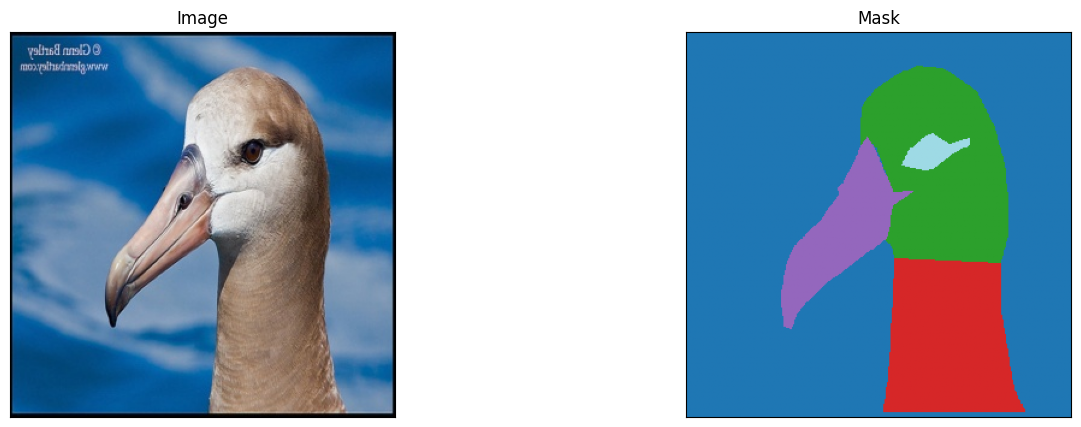

In [7]:
image, mask, _ = full_dataset[0]
print(f"Mask shape: {mask.shape}")
visualize(image=image, mask=mask)

In [8]:
model = load_segmentation(
            name=MODEL_NAME, 
            encoder_name=ENCODER_NAME, 
            checkpoint_path=MODEL_WEIGHTS
        )

In [9]:
test_iter = iter(test_loader)

/home/c/choton/miniconda3/envs/beemachine_new/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


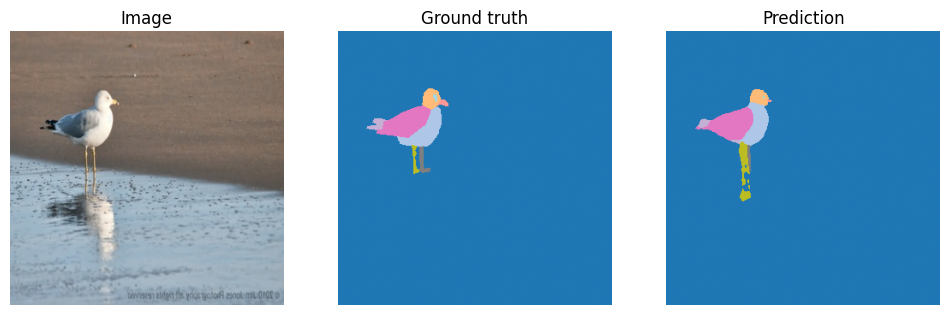

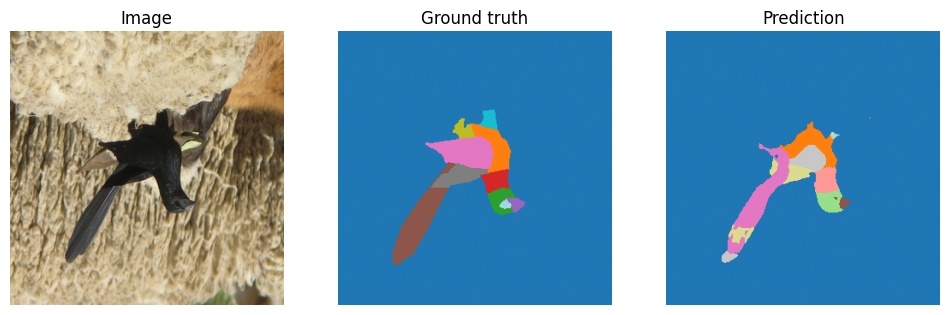

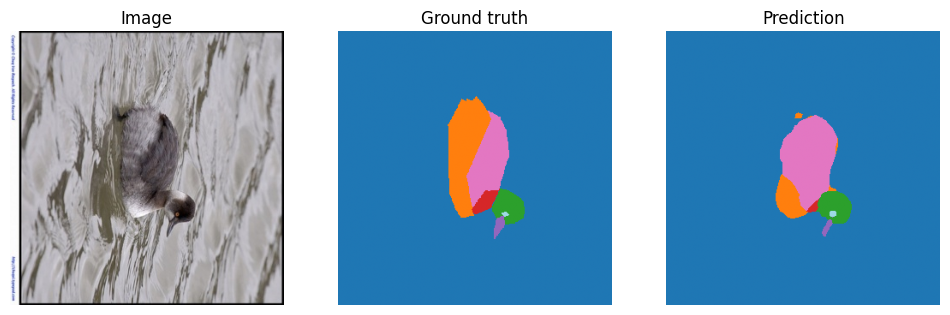

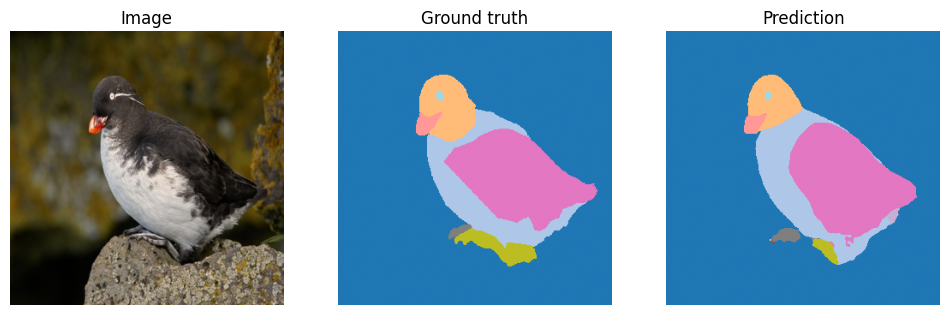

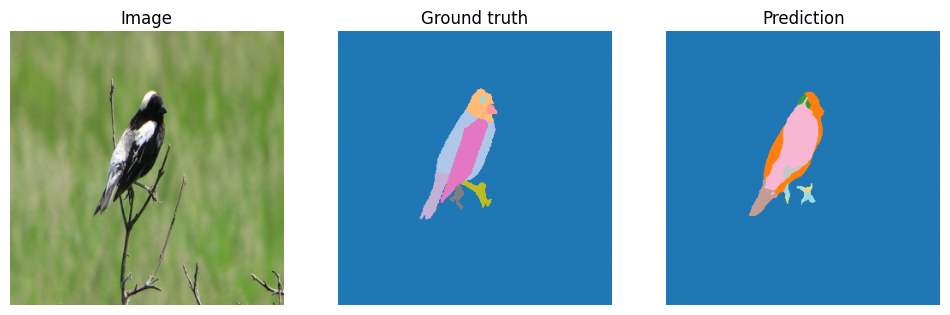

In [10]:
# Fetch a batch from the test loader
images, masks, _ = next(test_iter)

# Switch the model to evaluation mode
with torch.inference_mode():
    model.eval()
    logits = model(images)  # Get raw logits from the model

# Apply softmax to get class probabilities
# Shape: [batch_size, num_classes, H, W]

pr_masks = logits.softmax(dim=1)
# Convert class probabilities to predicted class labels
pr_masks = pr_masks.argmax(dim=1)  # Shape: [batch_size, H, W]

# Visualize a few samples (image, ground truth mask, and predicted mask)
for idx, (image, gt_mask, pr_mask) in enumerate(zip(images, masks, pr_masks)):
    if idx <= 4:  # Visualize first 5 samples
        plt.figure(figsize=(12, 6))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(
            image.cpu().numpy().transpose(1, 2, 0)
        )  # Convert CHW to HWC for plotting
        plt.title("Image")
        plt.axis("off")

        # Ground Truth Mask
        plt.subplot(1, 3, 2)
        plt.imshow(gt_mask.cpu().numpy(), cmap="tab20")  # Visualize ground truth mask
        plt.title("Ground truth")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask.cpu().numpy(), cmap="tab20")  # Visualize predicted mask
        plt.title("Prediction")
        plt.axis("off")

        # Show the figure
        plt.show()
    else:
        break

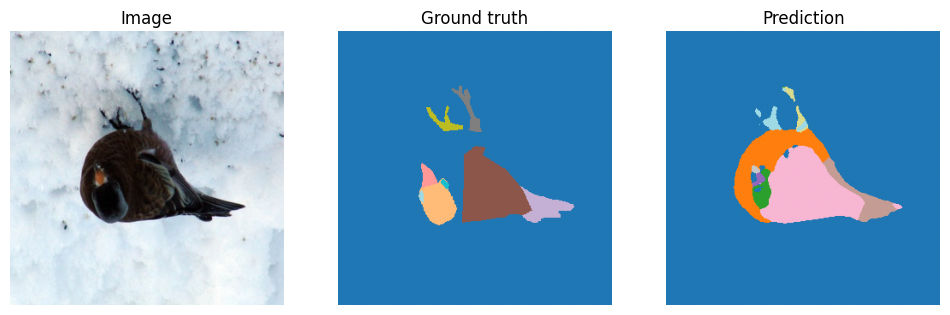

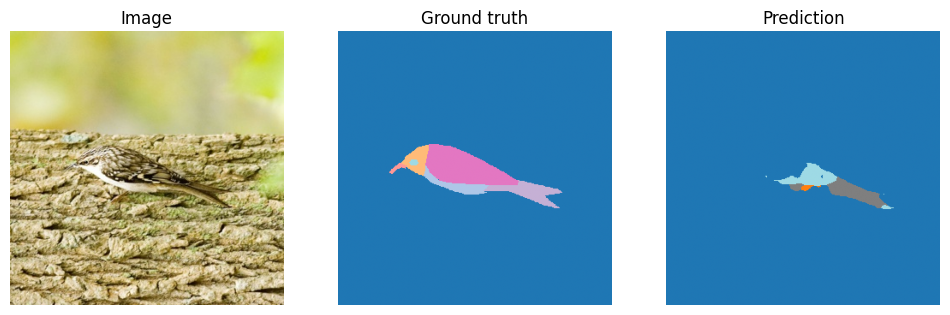

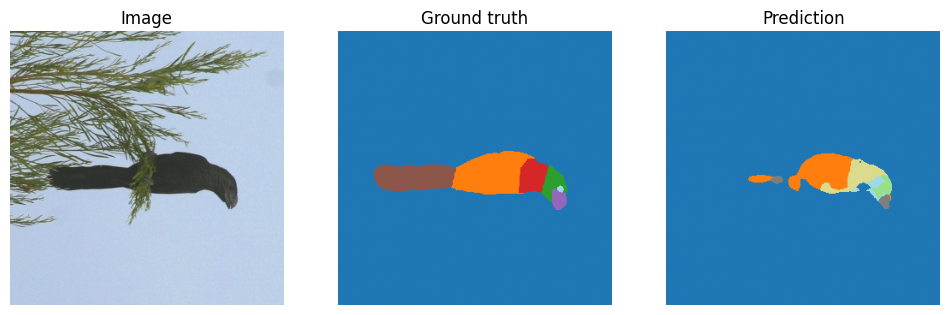

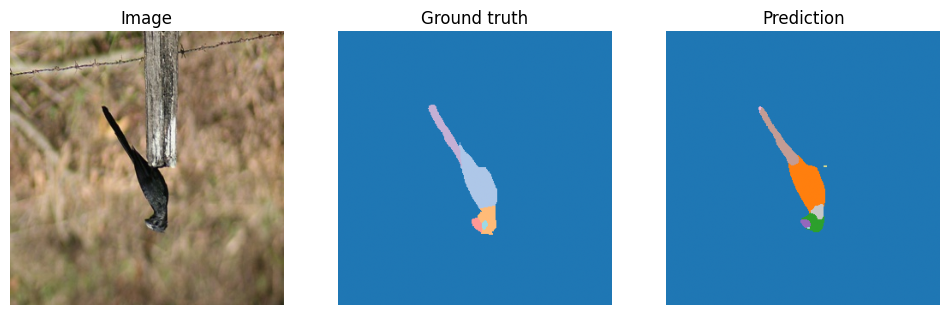

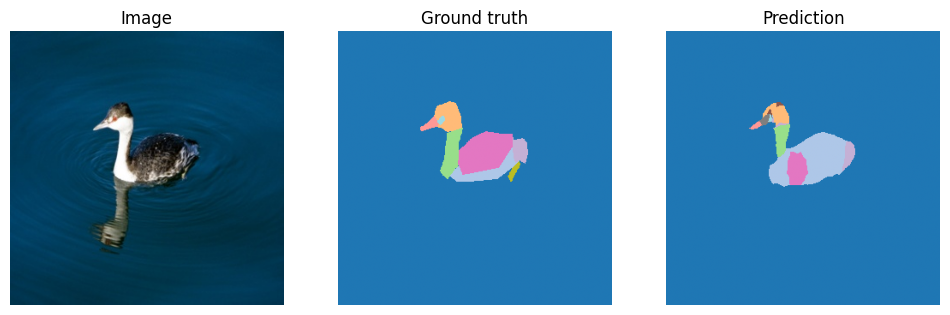

In [11]:
# Fetch a batch from the test loader
images, masks, _ = next(test_iter)

# Switch the model to evaluation mode
with torch.inference_mode():
    model.eval()
    logits = model(images)  # Get raw logits from the model

# Apply softmax to get class probabilities
# Shape: [batch_size, num_classes, H, W]

pr_masks = logits.softmax(dim=1)
# Convert class probabilities to predicted class labels
pr_masks = pr_masks.argmax(dim=1)  # Shape: [batch_size, H, W]

# Visualize a few samples (image, ground truth mask, and predicted mask)
for idx, (image, gt_mask, pr_mask) in enumerate(zip(images, masks, pr_masks)):
    if idx <= 4:  # Visualize first 5 samples
        plt.figure(figsize=(12, 6))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(
            image.cpu().numpy().transpose(1, 2, 0)
        )  # Convert CHW to HWC for plotting
        plt.title("Image")
        plt.axis("off")

        # Ground Truth Mask
        plt.subplot(1, 3, 2)
        plt.imshow(gt_mask.cpu().numpy(), cmap="tab20")  # Visualize ground truth mask
        plt.title("Ground truth")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask.cpu().numpy(), cmap="tab20")  # Visualize predicted mask
        plt.title("Prediction")
        plt.axis("off")

        # Show the figure
        plt.show()
    else:
        break

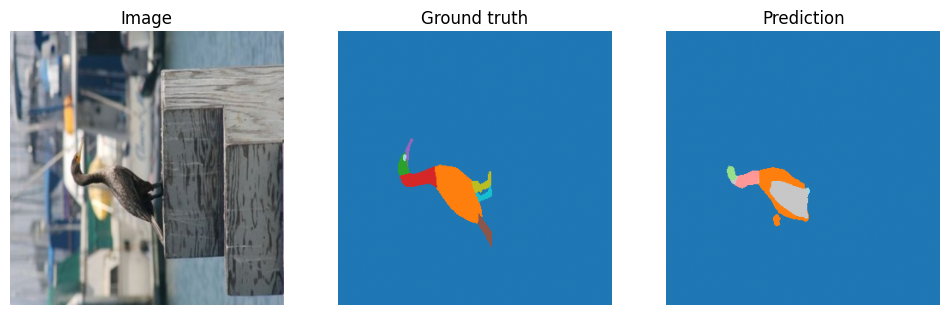

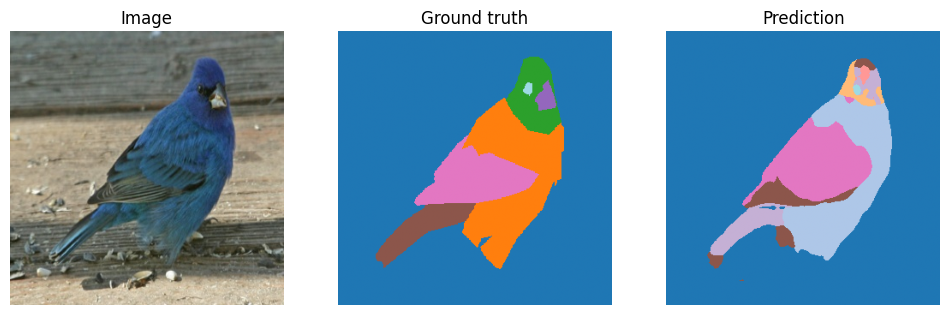

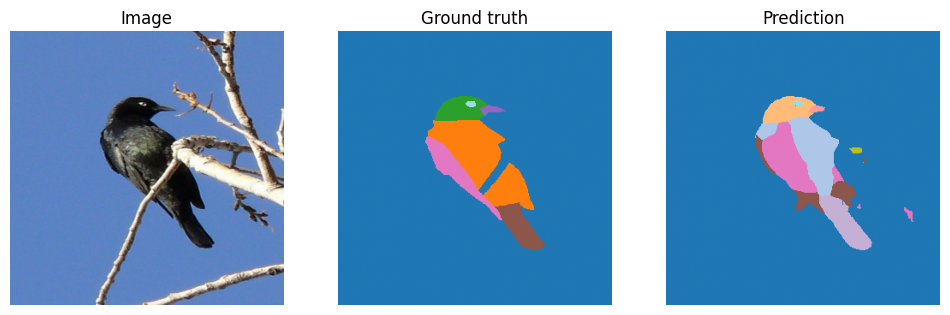

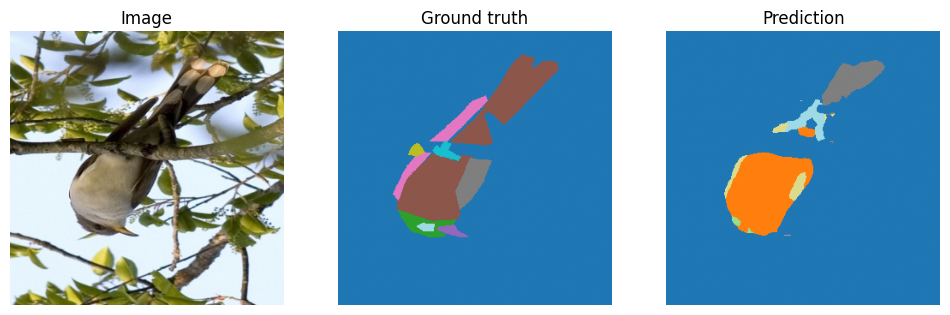

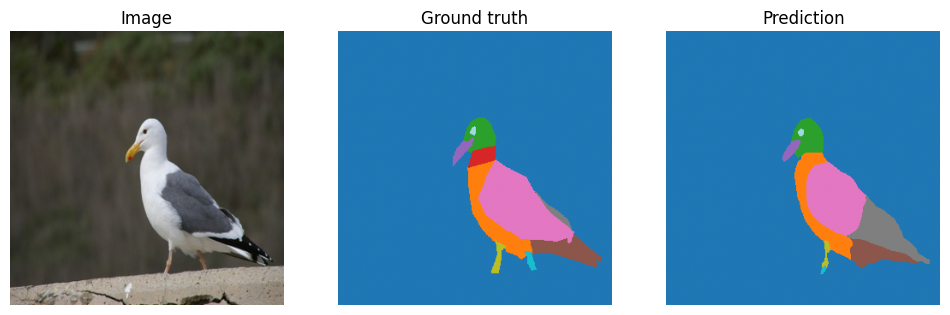

In [12]:
# Fetch a batch from the test loader
images, masks, _ = next(test_iter)

# Switch the model to evaluation mode
with torch.inference_mode():
    model.eval()
    logits = model(images)  # Get raw logits from the model

# Apply softmax to get class probabilities
# Shape: [batch_size, num_classes, H, W]

pr_masks = logits.softmax(dim=1)
# Convert class probabilities to predicted class labels
pr_masks = pr_masks.argmax(dim=1)  # Shape: [batch_size, H, W]

# Visualize a few samples (image, ground truth mask, and predicted mask)
for idx, (image, gt_mask, pr_mask) in enumerate(zip(images, masks, pr_masks)):
    if idx <= 4:  # Visualize first 5 samples
        plt.figure(figsize=(12, 6))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(
            image.cpu().numpy().transpose(1, 2, 0)
        )  # Convert CHW to HWC for plotting
        plt.title("Image")
        plt.axis("off")

        # Ground Truth Mask
        plt.subplot(1, 3, 2)
        plt.imshow(gt_mask.cpu().numpy(), cmap="tab20")  # Visualize ground truth mask
        plt.title("Ground truth")
        plt.axis("off")

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask.cpu().numpy(), cmap="tab20")  # Visualize predicted mask
        plt.title("Prediction")
        plt.axis("off")

        # Show the figure
        plt.show()
    else:
        break